In [9]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import datasets
import warnings

In [11]:
# Загрузка данных
df = pd.read_csv('dc.csv', index_col=0, parse_dates=True)

In [37]:
# Формирование датасета
D1 = df[['open_USD', 'high_USD', 'low_USD', 'close_USD', 'volume']].copy()

In [39]:
D1.head()

,open_USD,high_USD,low_USD,close_USD,volume
2021-01-30,34246.28,34933.00,32825.00,34218.54,43072
2021-01-29,33368.18,38531.90,31915.40,34252.20,231827
2021-01-28,30362.19,33783.98,29842.10,33364.86,92621
2021-01-27,32464.01,32557.29,29241.72,30366.15,95911
2021-01-26,32254.19,32921.88,30837.37,32467.77,84972


In [41]:
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1)
print('Доля объясненной дисперсии: {}, сумма={}'.format(pca.explained_variance_ratio_, np.sum(pca.explained_variance_ratio_)))
X_reduced[:10]

Доля объясненной дисперсии: [0.92006049 0.07979599], сумма=0.9998564805334575


array([[ -2784.12414305,  50476.46045299],
       [184160.70298604,  24269.2435817 ],
       [ 45622.34162293,  38990.60894559],
       [ 48676.05812087,  37146.36858776],
       [ 38120.66285867,  40609.24176005],
       [ 41818.67139501,  41505.81785833],
       [ 11397.00070736,  44415.22536186],
       [ 18056.25721461,  44230.81419327],
       [ 95389.81037615,  31318.7566824 ],
       [ 84736.93976543,  35650.51128924]])

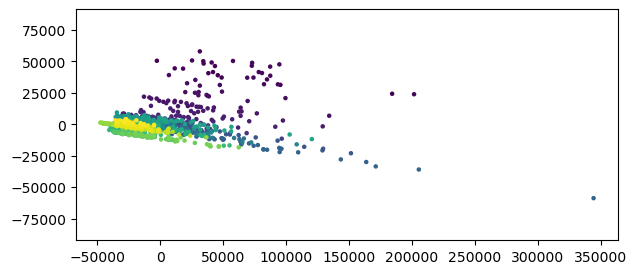

In [43]:
plt.figure(figsize=(7, 3))
plt.scatter(D2[:, 0], X_reduced[:, 1], s=5, c=range(len(data)))
plt.axis('equal')
plt.show()

In [45]:
tsne = TSNE(n_components=2)
D3 = tsne.fit_transform(D1)
D3[:10]

array([[34.418095,  8.826438],
       [55.20953 , 17.096315],
       [39.575253,  9.158447],
       [40.013004,  9.148077],
       [38.546997,  8.836407],
       [39.000656,  9.198366],
       [35.24047 ,  8.732154],
       [35.9393  ,  8.776528],
       [46.61043 , 12.782061],
       [45.9283  , 12.023241]], dtype=float32)

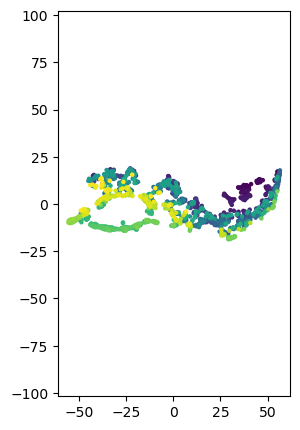

In [47]:
plt.figure(figsize=(3,5))
plt.scatter(D3[:, 0], D3[:, 1], s=5, c=range(len(data)))
plt.axis('equal')
plt.show()

# ------>  Более четкие кластеры выделяются на графике D3 (t-SNE).

In [51]:
def do_clustering(cluster_datasets, method):
    """
    Выполнение кластеризации для данных примера
    """
    cluster_results = []
    for X in cluster_datasets:
        temp_cluster = method.fit_predict(X)
        cluster_results.append(temp_cluster)
    return cluster_results

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

cluster_datasets = [D1_scaled, D2, D3]

%time result_KMeans_3 = do_clustering(cluster_datasets, KMeans(n_clusters=3))

CPU times: user 24.9 ms, sys: 31.3 ms, total: 56.2 ms
Wall time: 59.9 ms


In [66]:
%time result_KMeans_5 = do_clustering(cluster_datasets, KMeans(n_clusters=5))

CPU times: user 27.5 ms, sys: 23.6 ms, total: 51.1 ms
Wall time: 25.6 ms


In [68]:
%time result_KMeans_plus_3 = do_clustering(cluster_datasets, KMeans(n_clusters=3, init='k-means++'))

CPU times: user 15.3 ms, sys: 8.59 ms, total: 23.9 ms
Wall time: 24.2 ms


In [70]:
%time result_KMeans_batch_3 = do_clustering(cluster_datasets, MiniBatchKMeans(n_clusters=3))

CPU times: user 79.5 ms, sys: 85.9 ms, total: 165 ms
Wall time: 61 ms


In [126]:
def visualize_clusters(cluster_datasets, cluster_results):
    """Визуализация результатов кластерного анализа"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (X, y_pred, ax) in enumerate(zip(cluster_datasets, cluster_results, axes)):
        # Определяем уникальные кластеры
        unique_labels = np.unique(y_pred)
        n_clusters = len(unique_labels)
        
        # Создаём цветовую палитру
        colors = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 3)))
        
        # Для DBSCAN добавляем чёрный цвет для шума (-1)
        if -1 in unique_labels:
            colors = np.vstack([colors, [0, 0, 0, 1]])
        
        # Рисуем scatter plot
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap=plt.cm.tab10, s=10, alpha=0.7, edgecolor='k', linewidth=0.3)
        
        ax.set_title(f'{datasets_names[i]}\nКластеров: {n_clusters}')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

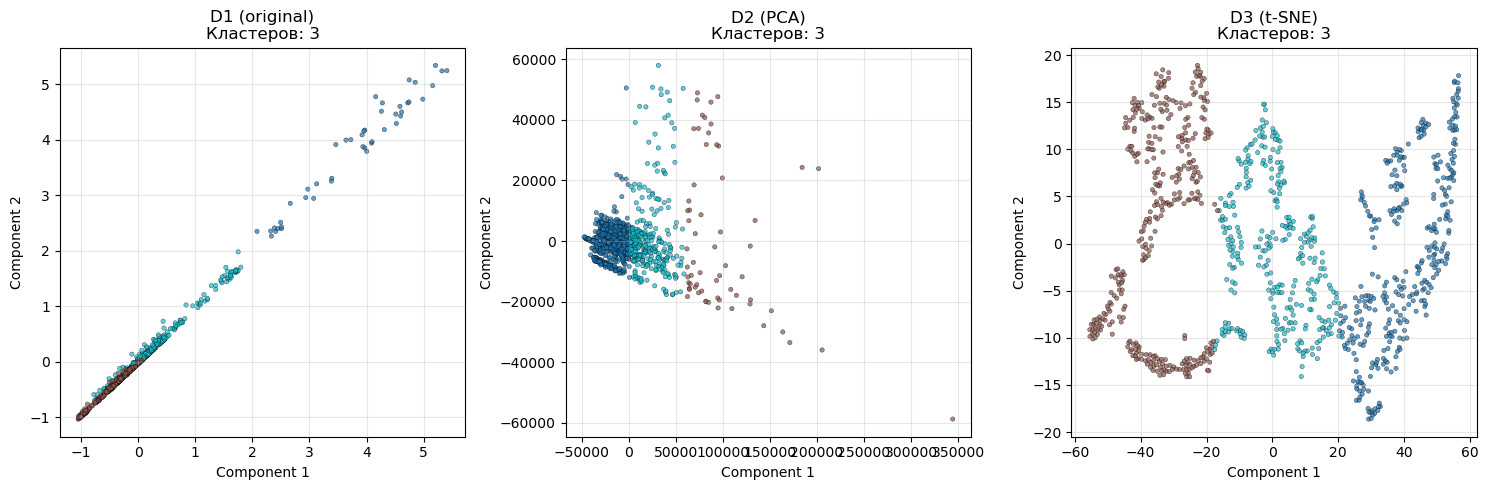

In [128]:
datasets_names = ['D1 (original)', 'D2 (PCA)', 'D3 (t-SNE)']
visualize_clusters(cluster_datasets, result_KMeans_3)

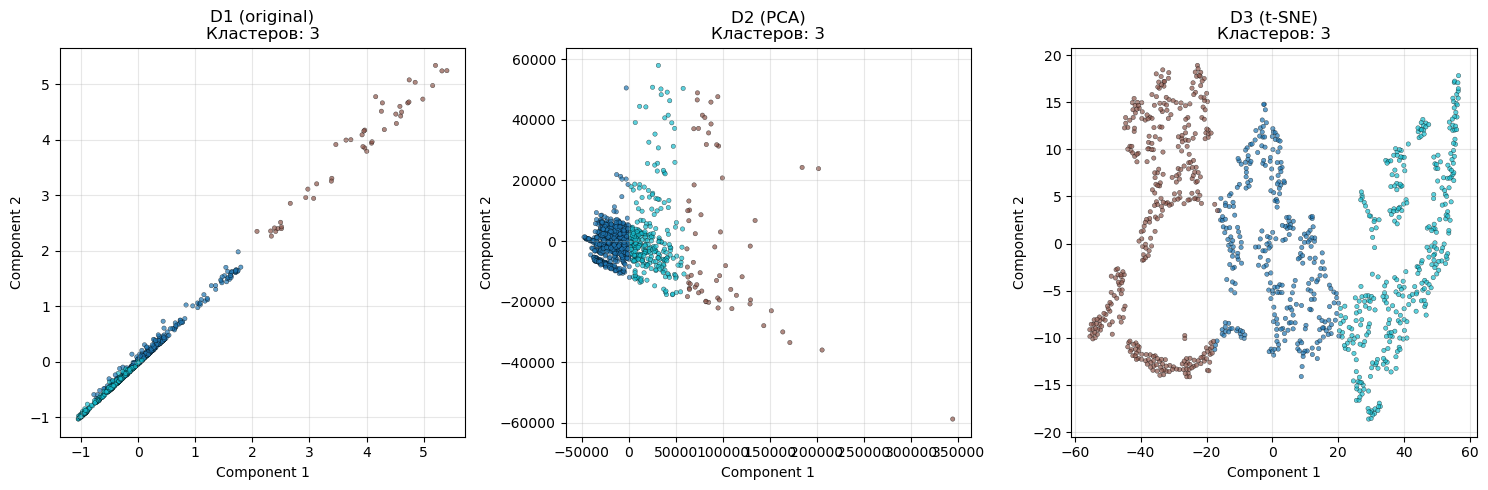

In [120]:
visualize_clusters(cluster_datasets, result_KMeans_plus_3)

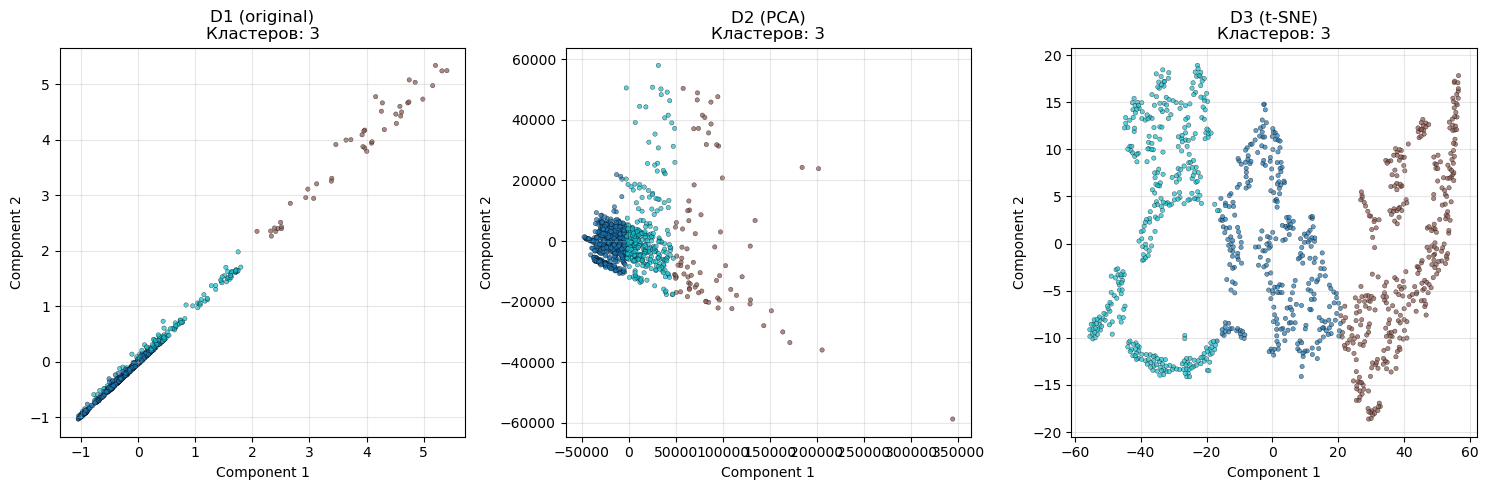

In [130]:
visualize_clusters(cluster_datasets, result_KMeans_batch_3)

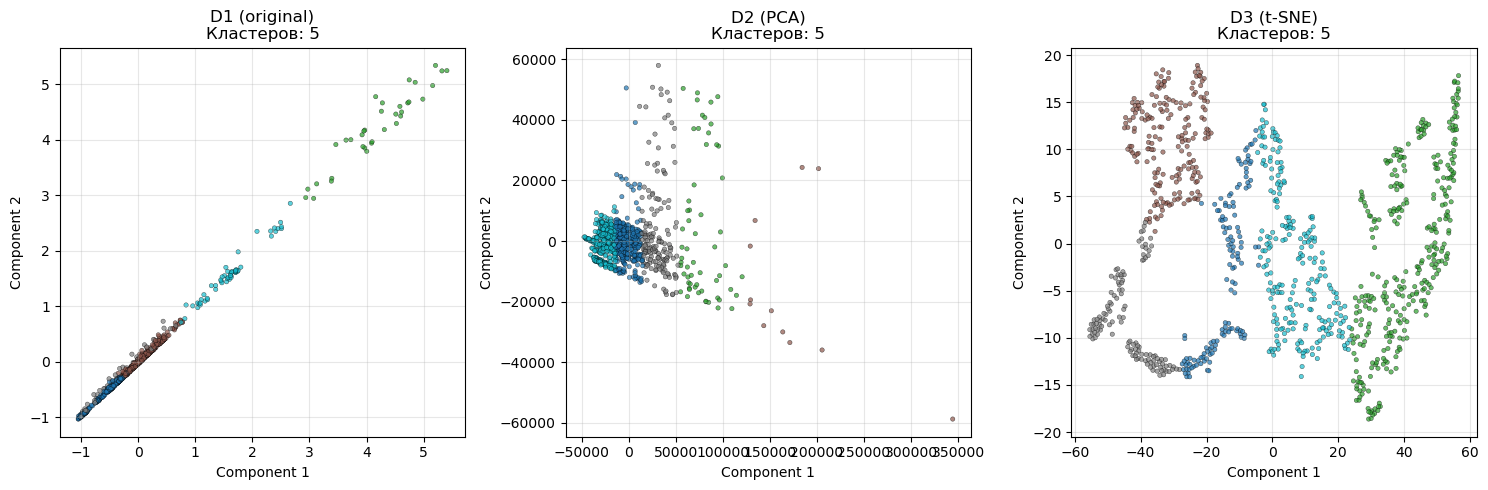

In [132]:
visualize_clusters(cluster_datasets, result_KMeans_5)

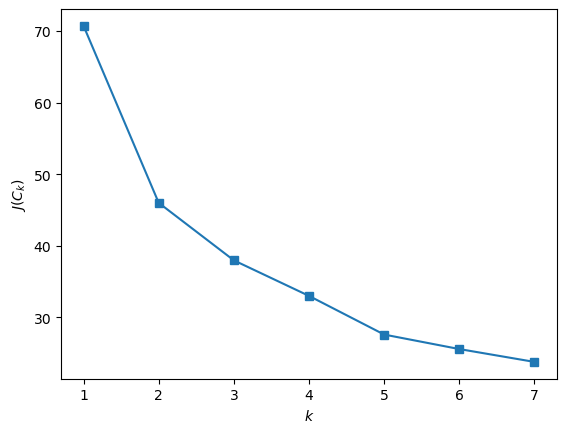

In [136]:
inertia = []
TEMP_X = cluster_datasets[0]
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(TEMP_X)
    inertia.append(np.sqrt(kmeans.inertia_))
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$');

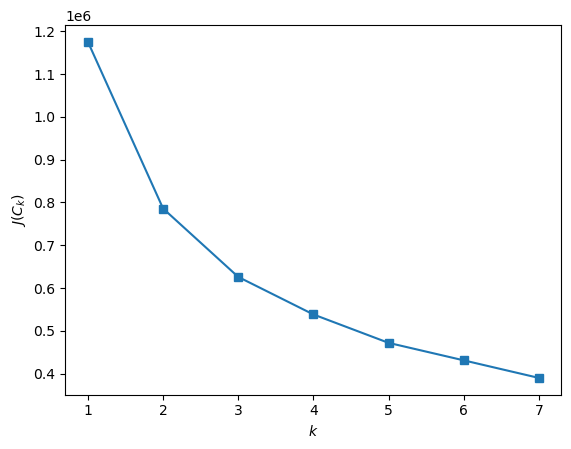

In [138]:
inertia = []
TEMP_X = cluster_datasets[1]
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(TEMP_X)
    inertia.append(np.sqrt(kmeans.inertia_))
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$');

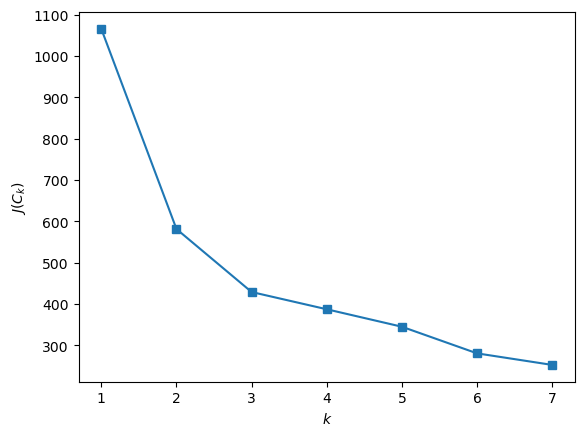

In [148]:
inertia = []
TEMP_X = cluster_datasets[2]
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(TEMP_X)
    inertia.append(np.sqrt(kmeans.inertia_))
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$');

In [164]:
from sklearn.metrics import (adjusted_rand_score, adjusted_mutual_info_score, 
                             homogeneity_completeness_v_measure, silhouette_score)
from sklearn.cluster import KMeans

def cluster_metrics(method, cluster_datasets, datasets_names, n_clusters=3):
    """
    Вычисление метрик кластеризации для ваших датасетов D1, D2, D3
    """
    ari = []
    ami = []
    hl = []
    cl = []
    vl = []
    sl = []
    
    for i, X in enumerate(cluster_datasets):
        # Применяем метод кластеризации
        temp_cluster = method.fit_predict(X)
        
        # Для ARI, AMI и других метрик используем результаты того же метода
        # как "эталон" (так как истинных меток нет)
        # ИЛИ создаем фиктивные метки через KMeans
        true_y = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X)
        
        # Вычисляем метрики
        ari.append(adjusted_rand_score(true_y, temp_cluster))
        ami.append(adjusted_mutual_info_score(true_y, temp_cluster))
        
        h, c, v = homogeneity_completeness_v_measure(true_y, temp_cluster)
        hl.append(h)
        cl.append(c)
        vl.append(v)
        
        # Silhouette Score
        try:
            sscore = silhouette_score(X, temp_cluster)
        except:
            sscore = None
        
        sl.append(sscore)
    
    # Создаем DataFrame с вашими названиями датасетов
    result = pd.DataFrame({
        'Datasets': datasets_names[0:3],  # Берем первые 3 (D1, D2, D3)
        'ARI': ari,
        'AMI': ami,
        'Homogeneity': hl,
        'Completeness': cl,
        'V-measure': vl,
        'Silhouette': sl
    })
    
    return result

In [168]:
# Для KMeans с 3 кластерами
cluster_metrics(KMeans(n_clusters=3), 
                cluster_datasets, 
                datasets_names)

,Datasets,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,D1 (original),0.856767,0.834414,0.843701,0.82615,0.834834,0.390969
1,D2 (PCA),1.000000,1.000000,1.000000,1.00000,1.000000,0.546114
2,D3 (t-SNE),0.997106,0.993812,0.993777,0.99387,0.993824,0.511359


In [176]:
cluster_metrics(KMeans(n_clusters=5), 
                cluster_datasets, 
                datasets_names)

,Datasets,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,D1 (original),0.340226,0.445141,0.555286,0.374688,0.447451,0.427516
1,D2 (PCA),0.410377,0.522225,0.676266,0.427941,0.524180,0.449499
2,D3 (t-SNE),0.582142,0.702976,0.864001,0.593803,0.703862,0.463748
